# Module 13, Assignment 1: PetFinder Multimodal Learning

**The Problem**

Every year, thousands of pets are listed online for adoption. Some are adopted quickly, while others take much longer. Predicting how fast a pet will be adopted can help shelters write better descriptions, prioritize resources, and improve adoption chances.

This is a multimodal prediction problem because each pet has multiple kinds of data:

- Tabular data (e.g., age, breed, color, sterilization status).

- Text descriptions (free-form text written by the shelter).

- Images (photos uploaded with the listing).

Our goal is to combine these different data sources and build a model that predicts the Adoption Speed of each pet.

**The Dataset:** PetFinder.my Adoption Data

We will use the PetFinder.my dataset, which was originally part of a Kaggle competition.

Size: ~12,000 training examples.

**Inputs:**

- Tabular: structured features about each pet.

- Text: a short description provided by the shelter.

- Images: at least one photo per pet.

- Target: AdoptionSpeed (0 = same day, 4 = not adopted after 100+ days).

For simplicity, we’ll turn this into a binary task:

- Fast adoption (adopted within 1 week) vs.

- Slow adoption (longer than 1 week).

We first install and load all the necessary packages.

In [ ]:
!pip -q install xgboost sentence-transformers timm autogluon

In [ ]:
download_dir = "./ag_petfinder_tutorial"
zip_file = "https://automl-mm-bench.s3.amazonaws.com/petfinder_kaggle.zip"

In [ ]:
from autogluon.core.utils.loaders import load_zip

load_zip.unzip(zip_file, unzip_dir=download_dir)

In [ ]:
import os, re, math, random, json, gc, sys, cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as tv_models

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [ ]:
os.listdir(download_dir)

['petfinder_processed', 'file.zip']

In [ ]:
dataset_path = download_dir + "/petfinder_processed"
os.listdir(dataset_path)

['test.csv', 'test_images', 'train_images', 'dev.csv', 'train.csv']

We now load and visualize the first 3 rows of the data we will use.

In [ ]:
train_csv = os.path.join(dataset_path, "train.csv")
img_root = os.path.join(dataset_path, "train_images")

df = pd.read_csv(train_csv, index_col=0)
print(df.shape)
df.head(3)

(11994, 25)


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,Images
10721,1,Elbi,2,307,307,2,5,0,0,3,...,1,0,41336,e9a86209c54f589ba72c345364cf01aa,0,I'm looking for people to adopt my dog,e4b90955c,4.0,4,train_images/e4b90955c-1.jpg;train_images/e4b9...
13114,2,Darling,4,266,0,1,1,0,0,2,...,1,0,41401,01f954cdf61526daf3fbeb8a074be742,0,Darling was born at the back lane of Jalan Alo...,a0c1384d1,5.0,3,train_images/a0c1384d1-1.jpg;train_images/a0c1...
13194,1,Wolf,3,307,0,1,1,2,0,2,...,1,0,41332,6e19409f2847326ce3b6d0cec7e42f81,0,I found Wolf about a month ago stuck in a drai...,cf357f057,7.0,4,train_images/cf357f057-1.jpg;train_images/cf35...


### Problem 1.1

### Data Fields

- **PetID** - Unique hash ID of pet profile
- **AdoptionSpeed** - Categorical speed of adoption. Lower is faster.
- **Type** - Type of animal (1 = Dog, 2 = Cat)
- **Name** - Name of pet (Empty if not named)
- **Age** - Age of pet when listed, in months
- **Breed1** - Primary breed of pet (Refer to BreedLabels dictionary)
- **Breed2** - Secondary breed of pet, if pet is of mixed breed (Refer to BreedLabels dictionary)
- **Gender** - Gender of pet (1 = Male, 2 = Female, 3 = Mixed, if profile represents group of pets)
- **Color1** - Color 1 of pet (Refer to ColorLabels dictionary)
- **Color2** - Color 2 of pet (Refer to ColorLabels dictionary)
- **Color3** - Color 3 of pet (Refer to ColorLabels dictionary)
- **MaturitySize** - Size at maturity (1 = Small, 2 = Medium, 3 = Large, 4 = Extra Large, 0 = Not Specified)
- **FurLength** - Fur length (1 = Short, 2 = Medium, 3 = Long, 0 = Not Specified)
- **Vaccinated** - Pet has been vaccinated (1 = Yes, 2 = No, 3 = Not Sure)
- **Dewormed** - Pet has been dewormed (1 = Yes, 2 = No, 3 = Not Sure)
- **Sterilized** - Pet has been spayed / neutered (1 = Yes, 2 = No, 3 = Not Sure)
- **Health** - Health Condition (1 = Healthy, 2 = Minor Injury, 3 = Serious Injury, 0 = Not Specified)
- **Quantity** - Number of pets represented in profile
- **Fee** - Adoption fee (0 = Free)
- **State** - State location in Malaysia (Refer to StateLabels dictionary)
- **RescuerID** - Unique hash ID of rescuer
- **VideoAmt** - Total uploaded videos for this pet
- **PhotoAmt**- Total uploaded photos for this pet
- **Description** - Profile write-up for this pet.

We now plot the distribution of AdoptionSpeed.

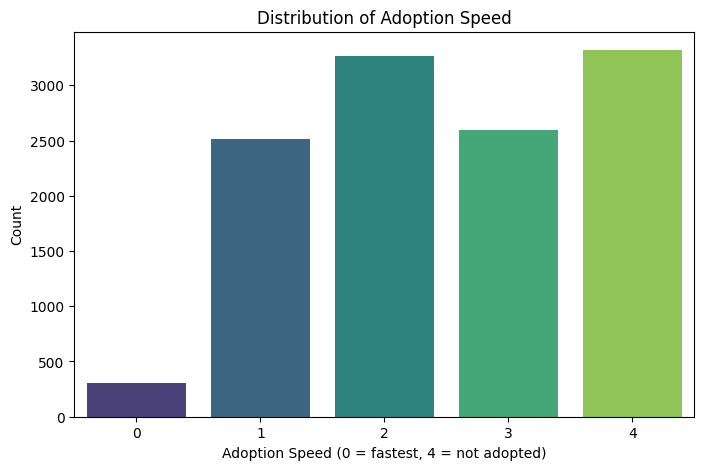

AdoptionSpeed
4    3319
2    3262
3    2596
1    2513
0     304
Name: count, dtype: int64


In [ ]:
# Plot distribution of AdoptionSpeed
plt.figure(figsize=(8, 5))
sns.countplot(x="AdoptionSpeed", data=df, palette="viridis")
plt.title("Distribution of Adoption Speed")
plt.xlabel("Adoption Speed (0 = fastest, 4 = not adopted)")
plt.ylabel("Count")
plt.show()

# Print counts
print(df["AdoptionSpeed"].value_counts())

We are now going to binarize the label, treating as fast adoption the pets that had an adoption speed of 0 or 1.

In [ ]:
# --- Quick peek: one example of tabular + text + image ---

import os, glob, textwrap, cv2
import pandas as pd
import matplotlib.pyplot as plt

ID_COL = "PetID"
TEXT_COL = "Description"
LABEL_COL = "AdoptionSpeed"

# Binary label: fast (0/1) -> 1 if AdoptionSpeed in {0,1}
df = df.copy()
df["fast_adopt"] = (df[LABEL_COL] <= 1).astype(int)

We also make sure that we keep the rows of the dataset that correspond to pets that have a description and at least one image.

In [ ]:
# Helper: get first available image path for a row
def first_image_path(row):
    if "Images" in df.columns and isinstance(row["Images"], str) and row["Images"]:
        # 'Images' may contain multiple paths separated by ';'
        p = row["Images"].split(";")[0].strip()
        # If it's already a full/relative path under train_images, trust it
        if os.path.exists(p):
            return p
        # Otherwise, try to join with the train_images folder
        candidate = os.path.join(img_root, os.path.basename(p))
        return candidate if os.path.exists(candidate) else None
    # Fallback: glob by PetID in train_images
    hits = sorted(glob.glob(os.path.join(img_root, f"{row[ID_COL]}*")))
    return hits[0] if hits else None


# Pick rows that actually have text + at least one image
mask = df[TEXT_COL].astype(str).str.strip().ne("")
df = df[mask].copy()
df["first_image"] = df.apply(first_image_path, axis=1)
df = df[df["first_image"].notnull()]

### Problem 1.4

We are now visualizing the data of the second entry of our dataframe.

,13114
Type,2
Age,4
Breed1,266
Breed2,0
Gender,1
Color1,1
Color2,0
Color3,0
MaturitySize,2
FurLength,1



--- Description (text) ---

Darling was born at the back lane of Jalan Alor and was foster by a feeder. All his
siblings had died of accident. His mother and grandmother had just been spayed. Darling
make a great condo/apartment cat. He love to play a lot. He would make a great companion
for someone looking for a cat to love.


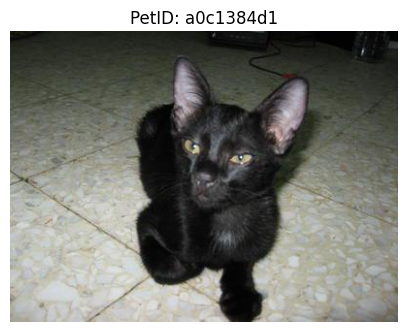

In [ ]:
row = df.iloc[1]

# Columns that are already numeric/int-coded
TAB_COLS = [
    "Type",
    "Age",
    "Breed1",
    "Breed2",
    "Gender",
    "Color1",
    "Color2",
    "Color3",
    "MaturitySize",
    "FurLength",
    "Vaccinated",
    "Dewormed",
    "Sterilized",
    "Health",
    "Quantity",
    "Fee",
    "VideoAmt",
    "PhotoAmt",
]

# --- 1) Show TABULAR snippet ---
tab_example = row[TAB_COLS].astype(object)  # keep ints readable
display(pd.DataFrame(tab_example).rename(columns={0: "Value"}))

# --- 2) Show TEXT snippet ---
wrapped = "\n".join(textwrap.wrap(str(row[TEXT_COL]).strip(), width=90))
print("\n--- Description (text) ---\n")
print(wrapped)

# --- 3) Show IMAGE ---
img_path = row["first_image"]
img = cv2.imread(img_path, cv2.IMREAD_COLOR)
if img is None:
    print(f"\n[warning] Could not load image: {img_path}")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"PetID: {row[ID_COL]}")
    plt.show()

## Embeddings extraction

In this part, we are going to extract embeddings from each of the different modalities — tabular, text, and images.

For tabular data, we transform categorical and numeric features into a structured embedding space.

For text descriptions, we use a pre-trained language model to capture the semantic meaning of each pet’s profile.

For images, we use a convolutional neural network (ResNet18) to generate feature vectors that represent visual characteristics of the pets.

These embeddings provide a unified numerical representation across modalities, making it possible to train models that combine heterogeneous inputs.

## Tabular embeddings


### Problem 2.1

In [ ]:
# Tabular embedding (same idea as MIMIC: just select numeric/int-coded)

TAB_COLS = [
    "Type",
    "Age",
    "Breed1",
    "Breed2",
    "Gender",
    "Color1",
    "Color2",
    "Color3",
    "MaturitySize",
    "FurLength",
    "Vaccinated",
    "Dewormed",
    "Sterilized",
    "Health",
    "Quantity",
    "Fee",
    "VideoAmt",
    "PhotoAmt",  # removed State
]
tab_df = df[[ID_COL, "fast_adopt"] + TAB_COLS].copy()
print("tab_df:", tab_df.shape)

tab_df: (11994, 20)


We now count the NaN values of the tabular features.

In [ ]:
print(tab_df.isna().sum())

PetID           0
fast_adopt      0
Type            0
Age             0
Breed1          0
Breed2          0
Gender          0
Color1          0
Color2          0
Color3          0
MaturitySize    0
FurLength       0
Vaccinated      0
Dewormed        0
Sterilized      0
Health          0
Quantity        0
Fee             0
VideoAmt        0
PhotoAmt        0
dtype: int64


## Text embeddings

### Problems 2.2-2.3

In [ ]:
# Text embeddings with SentenceTransformers (no chunking needed for these short descriptions)
def get_text_embeddings(
    texts,
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    batch_size=256,
    device=None,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = SentenceTransformer(model_name, device=device)
    # returns a (N, D) numpy array
    emb = model.encode(
        list(texts),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    )
    return emb


texts = df[TEXT_COL].fillna("").astype(str)
text_emb = get_text_embeddings(texts)
text_cols = [f"text_emb_{i}" for i in range(text_emb.shape[1])]
text_df = pd.DataFrame(text_emb, columns=text_cols)
text_df.insert(0, ID_COL, df[ID_COL].values)
print("text_df:", text_df.shape)

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

text_df: (11994, 385)


## Image embeddings

### Problems 2.4-2.6

In [ ]:
# Simple image dataset + ResNet18 features
class PetImageDS(Dataset):
    def __init__(self, paths, root):
        self.paths = paths
        self.root = root
        self.tf = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Resize((224, 224)),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        rel = self.paths[i]
        # If the CSV already contains 'train_images/...' keep it; else join with root
        full = (
            rel
            if os.path.isabs(rel) or rel.startswith(img_root)
            else os.path.join(self.root, os.path.basename(rel))
        )
        img = cv2.imread(full, cv2.IMREAD_COLOR)
        if img is None:  # handle missing file
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.tf(img)


def get_resnet18_embeddings(paths, root, batch_size=64, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = torch.nn.Identity()  # take 512-d penultimate layer
    model = model.to(device)
    model.eval()

    ds = PetImageDS(paths, root)
    dl = DataLoader(
        ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True
    )

    feats = []
    with torch.no_grad():
        for xb in tqdm(dl, desc="Image embedding"):
            xb = xb.to(device)
            f = model(xb)  # (B, 512)
            feats.append(f.detach().cpu().numpy())
    feats = np.concatenate(feats, axis=0)
    return feats


img_paths = df["first_image"].values
img_emb = get_resnet18_embeddings(img_paths, img_root)
img_cols = [f"img_emb_{i}" for i in range(img_emb.shape[1])]
img_df = pd.DataFrame(img_emb, columns=img_cols)
img_df.insert(0, ID_COL, df[ID_COL].values)
print("img_df:", img_df.shape)

Image embedding: 100%|██████████| 188/188 [00:57<00:00,  3.29it/s]

img_df: (11994, 513)


## Prediction


### Problems 3.1-3.3

In [ ]:
# Align on PetID
dfs = [
    tab_df.set_index(ID_COL),
    text_df.set_index(ID_COL),
    img_df.set_index(ID_COL),
]
common_ids = list(set.intersection(*[set(d.index) for d in dfs]))
tab_aligned = dfs[0].loc[common_ids]
text_aligned = dfs[1].loc[common_ids]
img_aligned = dfs[2].loc[common_ids]

# Labels
y = tab_aligned["fast_adopt"].values.astype(int)
X_tab = tab_aligned.drop(columns=["fast_adopt"]).values
X_text = text_aligned.values
X_img = img_aligned.values


def train_xgb(X, y, n_est=300, max_depth=6, lr=0.2):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    clf = XGBClassifier(
        n_estimators=n_est,
        max_depth=max_depth,
        learning_rate=lr,
        eval_metric="logloss",
        tree_method="hist",
        device="cuda",
    )
    clf.fit(Xtr, ytr)
    p = clf.predict_proba(Xte)[:, 1]
    return p, roc_auc_score(yte, p), yte


preds, aucs = {}, {}

for name, X in [("tab", X_tab), ("text", X_text), ("img", X_img)]:
    print(f"\nTraining on {name}...")
    p, a, yte = train_xgb(X, y)
    preds[name] = p
    aucs[name] = a


Training on tab...

Training on text...

Training on img...


In [ ]:
print("\nAUC by modality:")
for k, v in aucs.items():
    print(f"{k:>8}: {v:.4f}")


AUC by modality:
     tab: 0.6728
    text: 0.6086
     img: 0.6312


## Early Fusion of modalities

So far, we trained models on each modality separately (tabular, text, image). However, each modality captures different aspects of the adoption process — structured attributes, textual descriptions, and visual appearance. Early fusion means we simply concatenate the embeddings from all modalities into a single feature vector and train a model on top.


This way, the model can learn interactions across modalities (e.g., certain breeds in certain images with certain textual cues), potentially improving predictive power.



### Problems 3.4- 3.6


Training on combined modalities...

AUC by modality:
     tab: 0.6728
    text: 0.6086
     img: 0.6312
combined: 0.6904


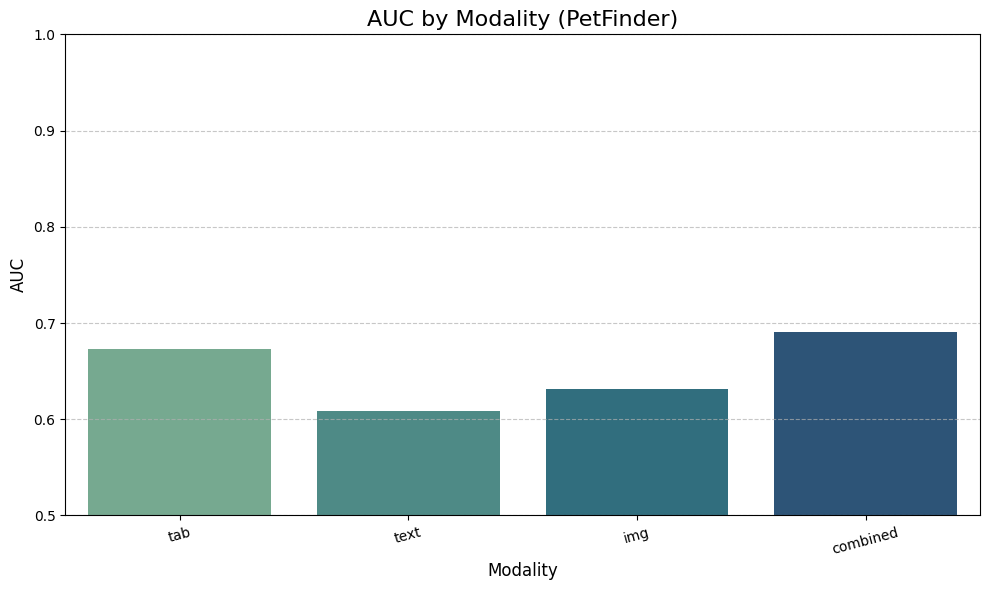

In [ ]:
# Fusion
X_all = np.hstack([X_tab, X_text, X_img])
print("\nTraining on combined modalities...")
p, a, yte = train_xgb(X_all, y)
preds["combined"] = p
aucs["combined"] = a

print("\nAUC by modality:")
for k, v in aucs.items():
    print(f"{k:>8}: {v:.4f}")

# Plot
auc_df = pd.DataFrame(list(aucs.items()), columns=["Modality", "AUC"])
plt.figure(figsize=(10, 6))
sns.barplot(data=auc_df, x="Modality", y="AUC", palette="crest")
plt.title("AUC by Modality (PetFinder)", fontsize=16)
plt.ylim(0.5, 1.0)
plt.ylabel("AUC", fontsize=12)
plt.xlabel("Modality", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Late Fusion

With late fusion, you don’t concatenate features. Instead, you train a separate model per modality (tabular, text, image) and then combine their predictions at the end—e.g., by averaging/weighting the predicted probabilities or training a small meta-model on those probabilities.


In [ ]:
# Store all probabilities from the different models in an array
probs = np.zeros((len(preds["tab"]), 3))
for i, modality in enumerate(["tab", "text", "img"]):
    probs[:, i] = preds[modality]

In [ ]:
print(
    f"AUC after combining all modalities (late fusion): {round(roc_auc_score(yte, np.sum(probs, axis=1)), 4)}"
)

AUC after combining all modalities (late fusion): 0.7056
